<a href="https://colab.research.google.com/github/Gowrav06/Data-Science/blob/main/Decision_Tree_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data handling
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [4]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [5]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_excel("heart_disease.xlsx", header=1)

df.head()

,Gender,"Gender ; Male - 1, Female -0"
0,cp,Chest pain type
1,trestbps,Resting blood pressure
2,chol,cholesterol measure
3,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...
4,restecg,"ecg observation at resting condition, -- Val..."


In [7]:
xls = pd.ExcelFile("heart_disease.xlsx")
xls.sheet_names

['Description', 'Heart_disease']

In [8]:
df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")

In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [10]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [11]:
df.shape

(908, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [13]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [14]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [15]:
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)

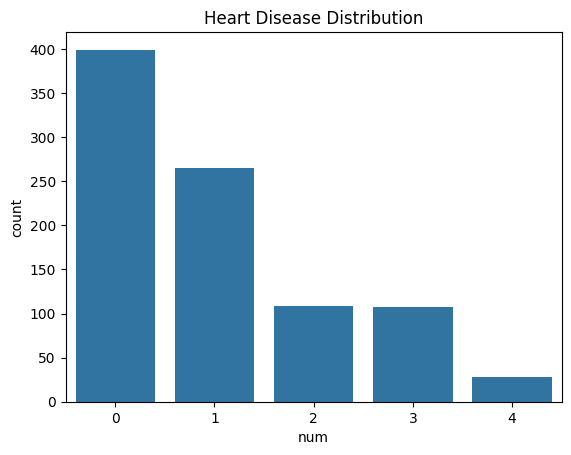

In [16]:
sns.countplot(x="num", data=df)
plt.title("Heart Disease Distribution")
plt.show()

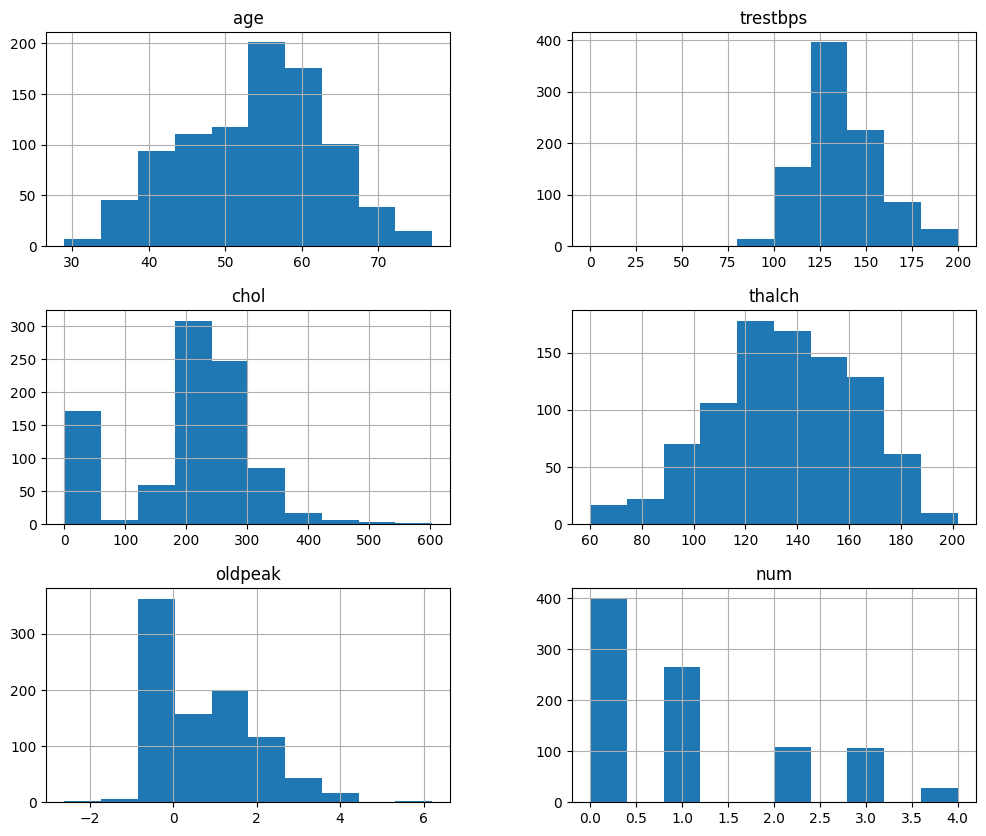

In [26]:
df.hist(figsize=(12,10))
plt.show()

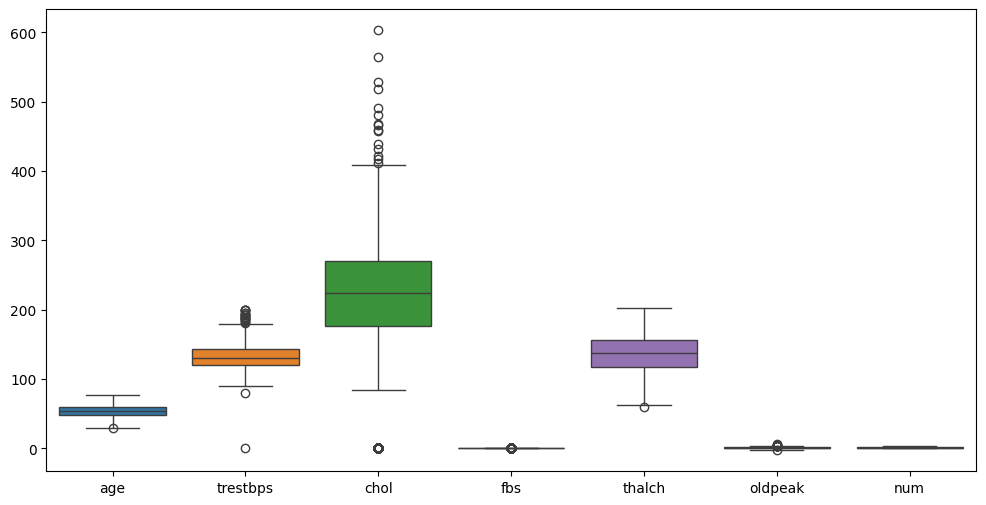

In [25]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

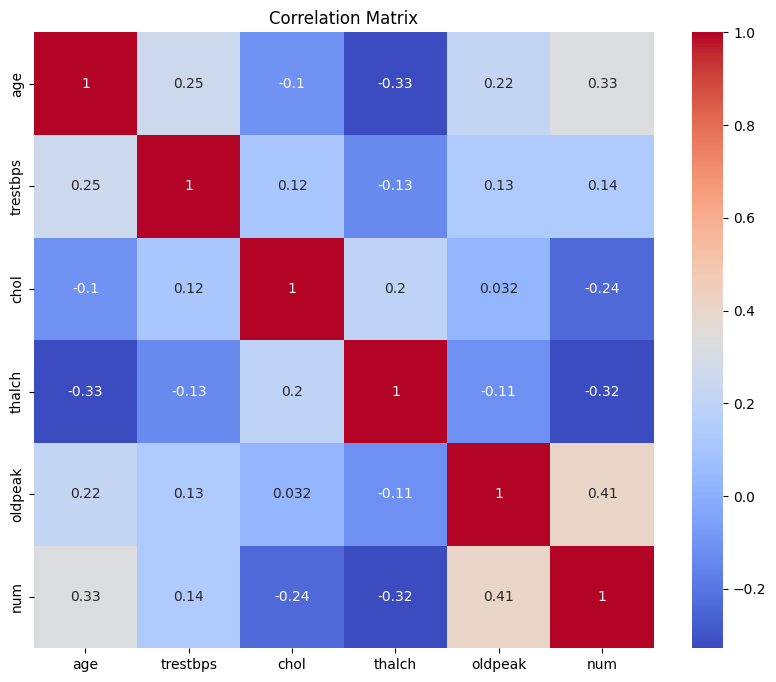

In [29]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [31]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, df[col].unique())

exang [False True 'FALSE' 'TURE']
slope ['downsloping' 'flat' 'upsloping']
thal ['fixed defect' 'normal' 'reversable defect']


In [32]:
for col in df.select_dtypes(include='object'):
    df[col] = df[col].astype(str)

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [34]:
X = df.drop("num", axis=1)

y = df["num"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [36]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [37]:
y_pred = dt_model.predict(X_test)

In [38]:
accuracy_score(y_test, y_pred)

0.532967032967033

In [40]:
print(y.unique())

[0 1 2 3 4]


In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Precision: 0.5297189360347255
Recall: 0.532967032967033
F1 Score: 0.5309141848710529


In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76        89
           1       0.39      0.35      0.37        48
           2       0.32      0.36      0.34        22
           3       0.21      0.24      0.22        17
           4       0.00      0.00      0.00         6

    accuracy                           0.53       182
   macro avg       0.33      0.34      0.34       182
weighted avg       0.53      0.53      0.53       182



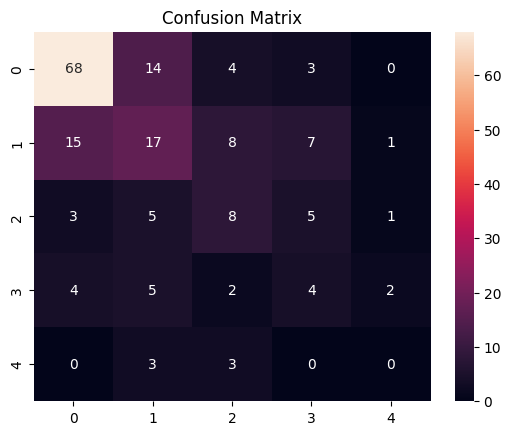

In [43]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [45]:
y_prob = dt_model.predict_proba(X_test)

roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6059204051035572


In [46]:
param_grid = {
    "max_depth":[3,5,10,None],
    "min_samples_split":[2,5,10],
    "criterion":["gini","entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [47]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

accuracy_score(y_test, best_pred)

0.5714285714285714

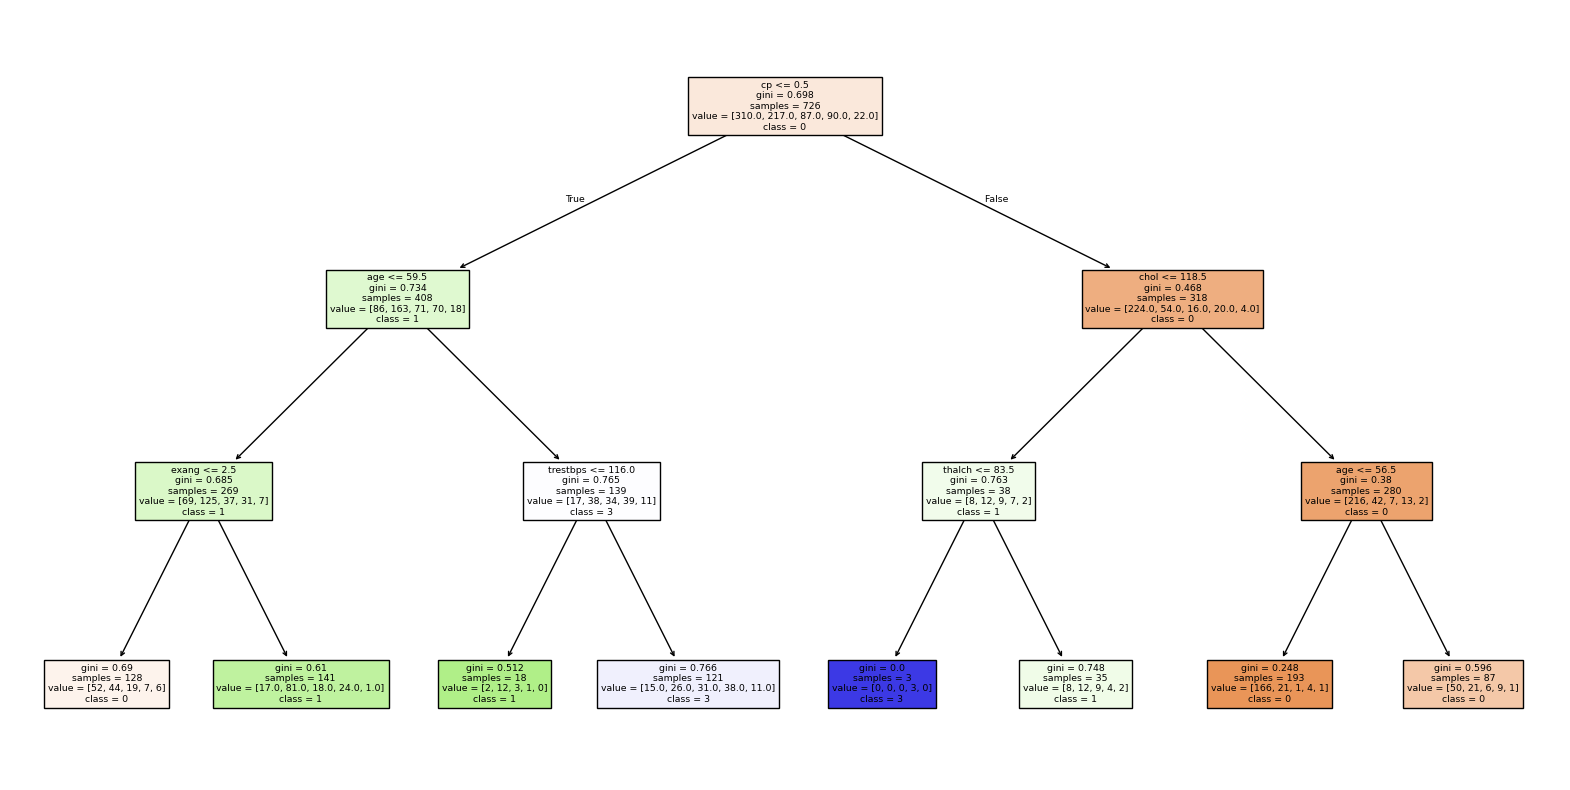

In [49]:
class_names = [str(i) for i in sorted(y.unique())]

plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=class_names,
    filled=True
)

plt.show()

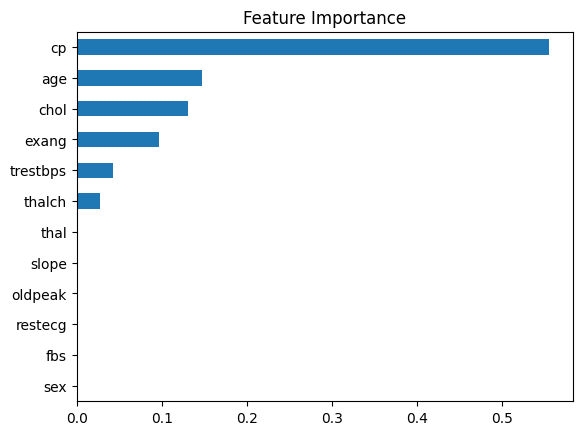

In [50]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.show()